In [29]:

#pip install langgraph langsmith
#pip install langchain langchain_groq langchain_community

In [ ]:
import os
os.environ['LANGSMITH_TRACING_V2'] = 'true'

In [31]:
from langchain_groq import ChatGroq

In [ ]:
llm = ChatGroq(
    groq_api_key=groq_api_key,
    model_name="qwen/qwen3.8-27b",
    temperature=0.7,
    max_tokens=512
)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, client=<groq.resources.chat.completions.Completions object at 0x0000025D6C6973B0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000025D6C6946B0>, model_name='qwen/qwen3.8-27b', model_kwargs={}, groq_api_key=SecretStr('**********'), max_tokens=512)

In [33]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [34]:
class State(TypedDict):
  # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
  messages:Annotated[list,add_messages]

graph_builder=StateGraph(State)

In [35]:
graph_builder

In [36]:
def chatbot(state:State):
  return {"messages":llm.invoke(state['messages'])}

In [37]:
graph_builder.add_node("chatbot",chatbot)

In [38]:
graph_builder

In [39]:
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

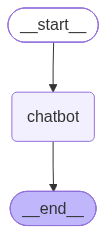

In [40]:
graph=graph_builder.compile()
graph

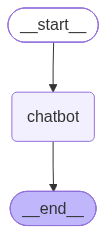

In [41]:
from IPython.display import Image, display
try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  pass

In [ ]:
from langchain_core.messages import HumanMessage

while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "q"]:
        print("Good Bye")
        break

    for event in graph.stream({"messages": [HumanMessage(content=user_input)]}):
        for value in event.values():
            msg = value["messages"]
            if hasattr(msg, "content"):
                print("Assistant:", msg.content)
            else:
                print(msg)
                
                
                
                

Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！有什么我可以帮你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！有什么我可以帮你的吗？
Assistant: 好的，请问有什么可以帮您的吗？
Assistant: 你好！我是通义千问，由阿里巴巴通义实验室独立开发的大语言模型。

请问有什么我可以帮你的吗？
Assistant: 你好！有什么我可以帮你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！有什么我可以帮你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！有什么我可以帮你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！有什么我可以帮你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: 你好！有什么我可以帮你的吗？
Assistant: Hello! How can I help you today?
Assistant: 你好！有什么我可以帮助你的吗？
Assistant: 你好！请问有什么我可以帮你的吗？
Assistant: Hi ther